# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 7
- Unchanged feature creation functions: 7 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time

Total Created Features:  257


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 9000
No validation set created.
Test set size: 3000


## 3. Feature Selection

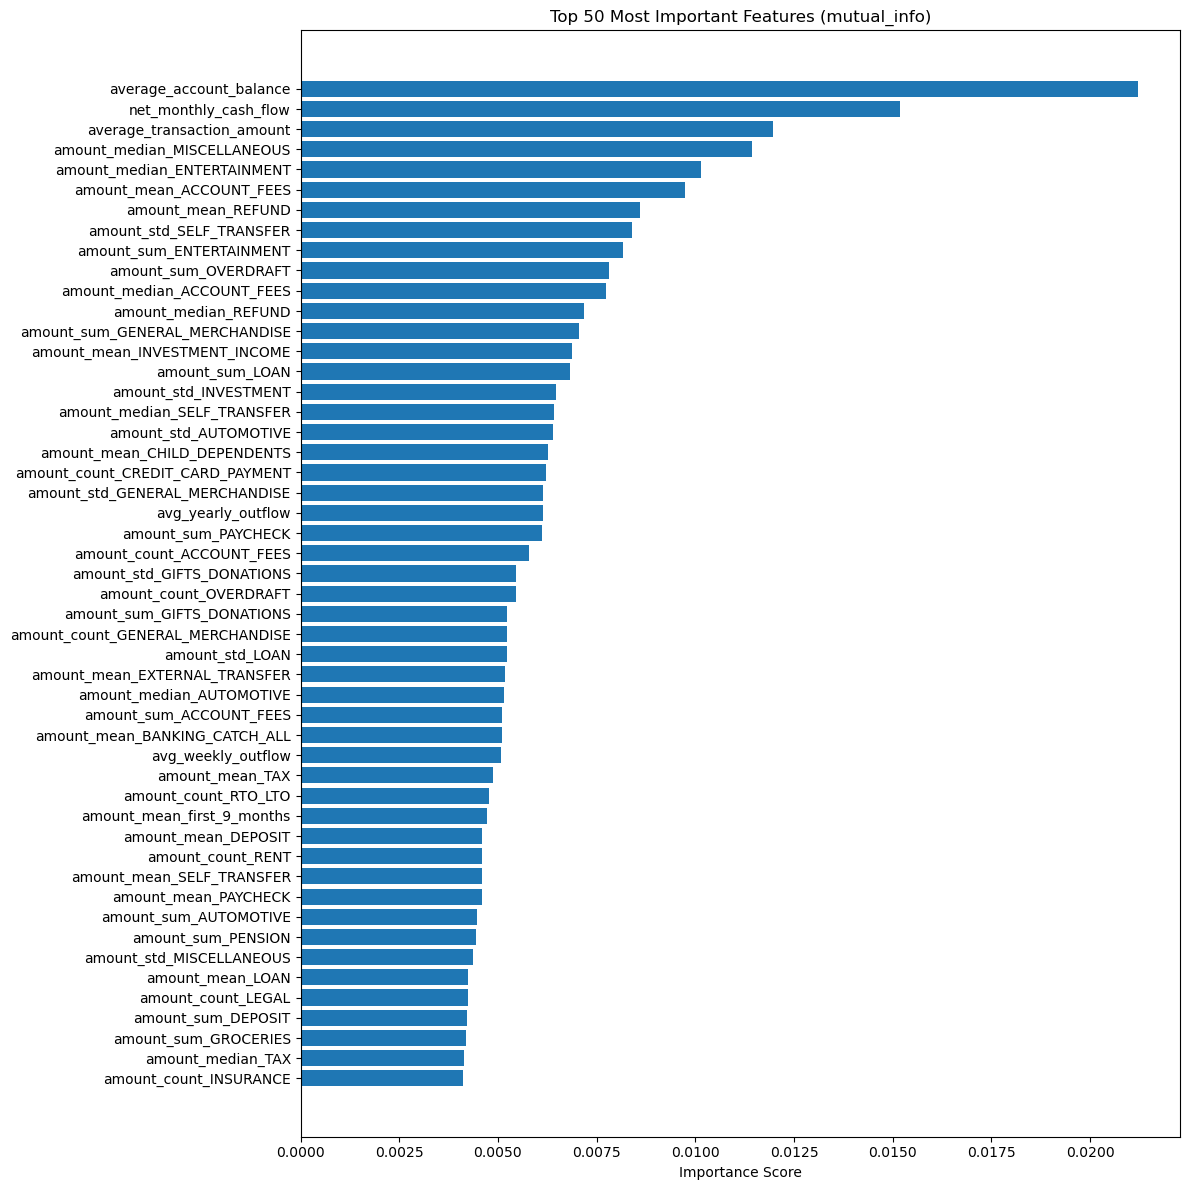

In [5]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

## 4. Model Performance

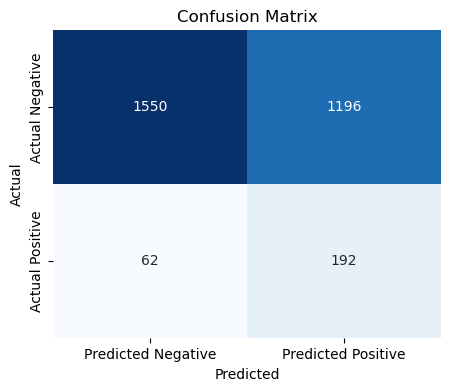

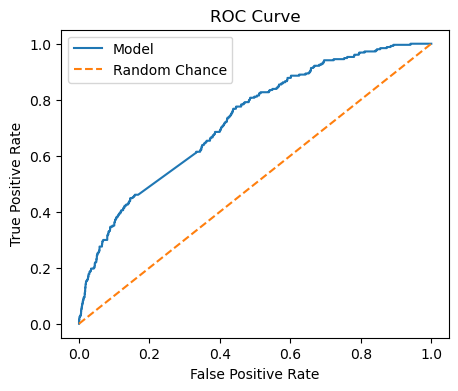

=== TEST METRICS ===
Accuracy: 0.5806666666666667
ROC AUC Score: 0.7267779619317432
Balanced Accuracy: 0.660181452191018

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1550                1196
Actual Positive                  62                 192

=== TRAINING METRICS ===
Train Accuracy: 0.6258888888888889
Train ROC AUC: 0.9053106201116453
Train Balanced Accuracy: 0.786825819798997


In [6]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

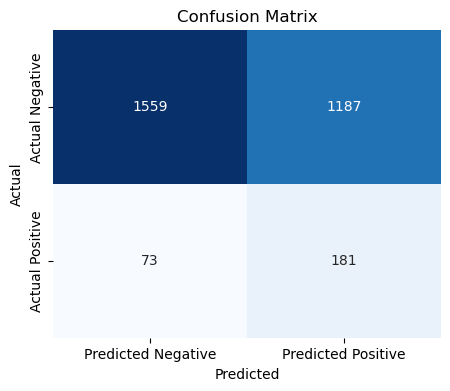

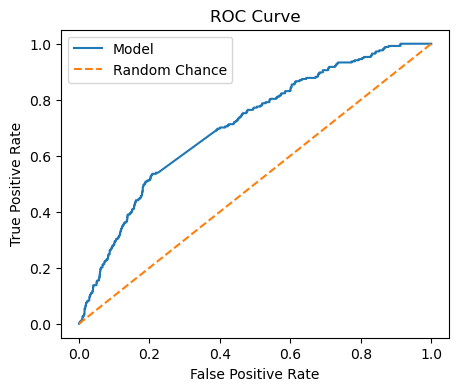

=== TEST METRICS ===
Accuracy: 0.58
ROC AUC Score: 0.7083130222342017
Balanced Accuracy: 0.640166656152686

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1559                1187
Actual Positive                  73                 181

=== TRAINING METRICS ===
Train Accuracy: 0.6012222222222222
Train ROC AUC: 0.7884402505056028
Train Balanced Accuracy: 0.7093150886352848


In [7]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

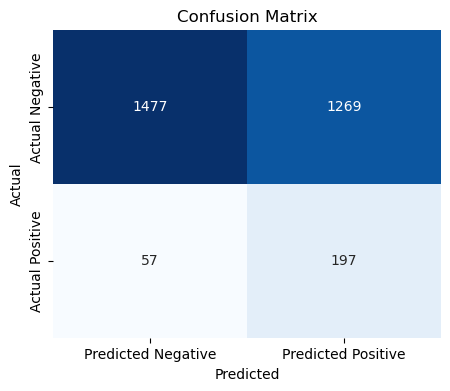

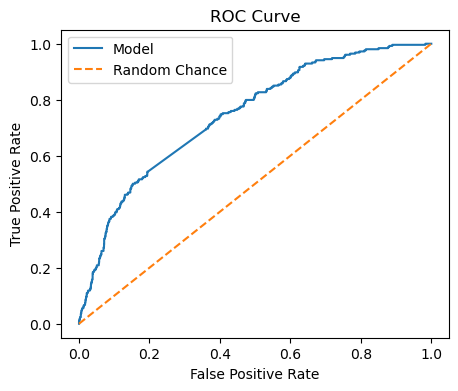

=== TEST METRICS ===
Accuracy: 0.558
ROC AUC Score: 0.7441848128415849
Balanced Accuracy: 0.6567319106961593

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1477                1269
Actual Positive                  57                 197

=== TRAINING METRICS ===
Train Accuracy: 0.5943333333333334
Train ROC AUC: 0.8796882738819984
Train Balanced Accuracy: 0.7629625234744206


In [8]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

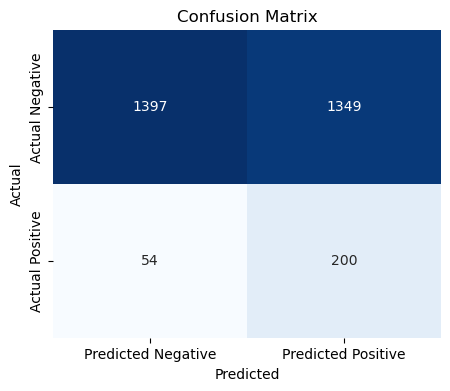

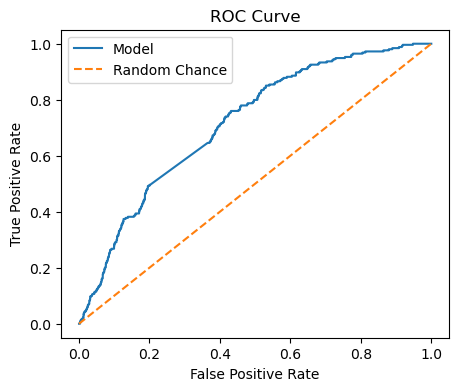

=== TEST METRICS ===
Accuracy: 0.5323333333333333
ROC AUC Score: 0.7145439895395449
Balanced Accuracy: 0.6480707801182537

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1397                1349
Actual Positive                  54                 200

=== TRAINING METRICS ===
Train Accuracy: 0.5468888888888889
Train ROC AUC: 0.7411733921311678
Train Balanced Accuracy: 0.6760459015209361


In [9]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)